In [1]:
from IPython.display import Markdown as md

### change to reflect your notebook
_nb_loc = "02_ml_models/02b_neural_network.ipynb"
_nb_title = "Flowers Image Classification using a neural network"

### no need to change any of this
_nb_safeloc = _nb_loc.replace('/', '%2F')
md("""
<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://console.cloud.google.com/ai-platform/notebooks/deploy-notebook?name={1}&url=https%3A%2F%2Fgithub.com%2FGoogleCloudPlatform%2Fpractical-ml-vision-book%2Fblob%2Fmaster%2F{2}&download_url=https%3A%2F%2Fgithub.com%2FGoogleCloudPlatform%2Fpractical-ml-vision-book%2Fraw%2Fmaster%2F{2}">
    <img src="https://raw.githubusercontent.com/GoogleCloudPlatform/practical-ml-vision-book/master/logo-cloud.png"/> Run in AI Platform Notebook</a>
  </td>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/GoogleCloudPlatform/practical-ml-vision-book/blob/master/{0}">
    <img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/GoogleCloudPlatform/practical-ml-vision-book/blob/master/{0}">
    <img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://raw.githubusercontent.com/GoogleCloudPlatform/practical-ml-vision-book/master/{0}">
    <img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>
""".format(_nb_loc, _nb_title, _nb_safeloc))


<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://console.cloud.google.com/ai-platform/notebooks/deploy-notebook?name=Flowers Image Classification using a neural network&url=https%3A%2F%2Fgithub.com%2FGoogleCloudPlatform%2Fpractical-ml-vision-book%2Fblob%2Fmaster%2F02_ml_models%2F02b_neural_network.ipynb&download_url=https%3A%2F%2Fgithub.com%2FGoogleCloudPlatform%2Fpractical-ml-vision-book%2Fraw%2Fmaster%2F02_ml_models%2F02b_neural_network.ipynb">
    <img src="https://raw.githubusercontent.com/GoogleCloudPlatform/practical-ml-vision-book/master/logo-cloud.png"/> Run in AI Platform Notebook</a>
  </td>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/GoogleCloudPlatform/practical-ml-vision-book/blob/master/02_ml_models/02b_neural_network.ipynb">
    <img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/GoogleCloudPlatform/practical-ml-vision-book/blob/master/02_ml_models/02b_neural_network.ipynb">
    <img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://raw.githubusercontent.com/GoogleCloudPlatform/practical-ml-vision-book/master/02_ml_models/02b_neural_network.ipynb">
    <img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>


# Flowers Image Classification using a neural network

In this notebook, we show how to build a neural network to classify the tf-flowers dataset.

Much of the data exploration was done in the companion notebook
02a_machine_perception.ipynb


## Enable GPU and set up helper functions

This notebook and pretty much every other notebook in this repository
will run faster if you are using a GPU.
On Colab:
- Navigate to Edit→Notebook Settings
- Select GPU from the Hardware Accelerator drop-down

On Cloud AI Platform Notebooks:
- Navigate to https://console.cloud.google.com/ai-platform/notebooks
- Create an instance with a GPU or select your instance and add a GPU

Next, we'll confirm that we can connect to the GPU with tensorflow:

In [2]:
import tensorflow as tf
print(tf.version.VERSION)
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

2.19.0
Found GPU at: /device:GPU:0


In [3]:
# Helper functions
def training_plot(metrics, history):
  f, ax = plt.subplots(1, len(metrics), figsize=(5*len(metrics), 5))
  for idx, metric in enumerate(metrics):
    ax[idx].plot(history.history[metric], ls='dashed')
    ax[idx].set_xlabel("Epochs")
    ax[idx].set_ylabel(metric)
    ax[idx].plot(history.history['val_' + metric]);
    ax[idx].legend([metric, 'val_' + metric])

# Call model.predict() on a few images in the evaluation dataset
def plot_predictions(filename):
  f, ax = plt.subplots(3, 5, figsize=(25,15))
  dataset = (tf.data.TextLineDataset(filename).
      map(decode_csv))
  for idx, (img, label) in enumerate(dataset.take(15)):
    ax[idx//5, idx%5].imshow((img.numpy()));
    batch_image = tf.reshape(img, [1, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS])
    batch_pred = model.predict(batch_image)
    pred = batch_pred[0]
    label = CLASS_NAMES[label.numpy()]
    pred_label_index = tf.math.argmax(pred).numpy()
    pred_label = CLASS_NAMES[pred_label_index]
    prob = pred[pred_label_index]
    ax[idx//5, idx%5].set_title('{}: {} ({:.4f})'.format(label, pred_label, prob))

def show_trained_weights(model):
  # CLASS_NAMES is ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
  LAYER = 1 # Layer 0 flattens the image, layer=1 is the first dense layer
  WEIGHT_TYPE = 0 # 0 for weight, 1 for bias

  f, ax = plt.subplots(1, 5, figsize=(15,15))
  for flower in range(len(CLASS_NAMES)):
    weights = model.layers[LAYER].get_weights()[WEIGHT_TYPE][:, flower]
    min_wt = tf.math.reduce_min(weights).numpy()
    max_wt = tf.math.reduce_max(weights).numpy()
    flower_name = CLASS_NAMES[flower]
    print("Scaling weights for {} in {} to {}".format(
        flower_name, min_wt, max_wt))
    weights = (weights - min_wt)/(max_wt - min_wt)
    ax[flower].imshow(weights.reshape(IMG_HEIGHT, IMG_WIDTH, 3));
    ax[flower].set_title(flower_name);

In [4]:
import matplotlib.pylab as plt
import numpy as np
import tensorflow as tf
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

def read_and_decode(filename, reshape_dims):
  # Read the file
  img = tf.io.read_file(filename)
  # Convert the compressed string to a 3D uint8 tensor.
  img = tf.image.decode_jpeg(img, channels=IMG_CHANNELS)
  # Use `convert_image_dtype` to convert to floats in the [0,1] range.
  img = tf.image.convert_image_dtype(img, tf.float32)
  # Resize the image to the desired size.
  return tf.image.resize(img, reshape_dims)

CLASS_NAMES = [item.numpy().decode("utf-8") for item in
               tf.strings.regex_replace(
                 tf.io.gfile.glob("gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/*"),
                 "gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/", "")]
CLASS_NAMES = [item for item in CLASS_NAMES if item.find(".") == -1]
print("These are the available classes:", CLASS_NAMES)

# the label is the index into CLASS_NAMES array
def decode_csv(csv_row):
  record_defaults = ["path", "flower"]
  filename, label_string = tf.io.decode_csv(csv_row, record_defaults)
  img = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])
  label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))
  return img, label

These are the available classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


## A Neural Network (NN) model

Adding one non-linear layer in the middle ...

In [5]:
BATCH_SIZE = 32

train_dataset = (tf.data.TextLineDataset(
    "gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/train_set.csv").
    map(decode_csv)).batch(BATCH_SIZE)

eval_dataset = (tf.data.TextLineDataset(
    "gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/eval_set.csv").
    map(decode_csv)).batch(BATCH_SIZE)

# NN with one hidden layer
model = tf.keras.Sequential([
          tf.keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
          tf.keras.layers.Dense(128, activation=tf.keras.activations.relu),
          tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax')
])
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])
history = model.fit(train_dataset, validation_data=eval_dataset, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
    104/Unknown 226s 2s/step - accuracy: 0.2705 - loss: 29.2535

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


104/104 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.3188 - loss: 13.3737 - val_accuracy: 0.3919 - val_loss: 2.3667
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.4200 - loss: 2.4311 - val_accuracy: 0.4270 - val_loss: 2.5156
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.4279 - loss: 3.0318 - val_accuracy: 0.4459 - val_loss: 2.5720
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.4273 - loss: 2.6261 - val_accuracy: 0.4216 - val_loss: 1.6057
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.4897 - loss: 1.3667 - val_accuracy: 0.3486 - val_loss: 1.5469
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.4318 - loss: 1.4239 - val_accuracy: 0.2297 - val_loss: 1.5689
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.4200 - loss: 1.3867 - val_accuracy: 0.3541 - val_loss: 1.5146
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.4033 - loss: 1.4402 - val_accuracy: 0.35

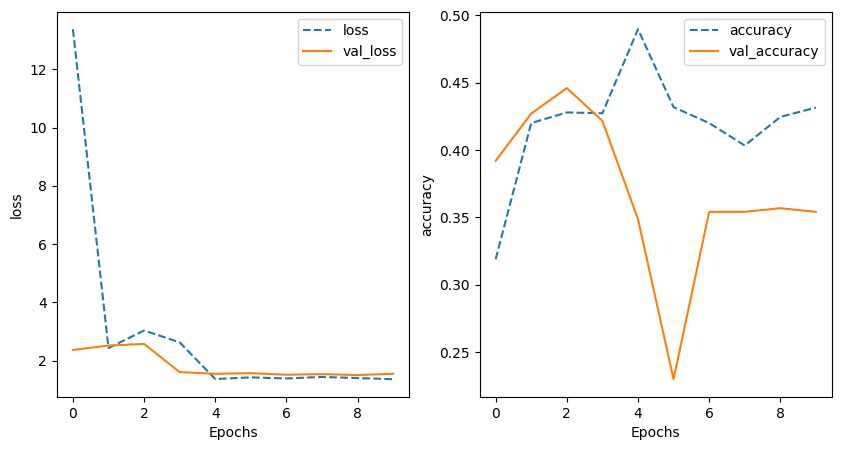

In [6]:
training_plot(['loss', 'accuracy'], history)

In [7]:
# parameterize to the values in the previous cell
def train_and_evaluate(batch_size = 32,
                       lrate = 0.001, # default in Adam constructor
                       l1 = 0,
                       l2 = 0,
                       num_hidden = 128):
  regularizer = tf.keras.regularizers.l1_l2(l1, l2)

  train_dataset = (tf.data.TextLineDataset(
      "gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/train_set.csv").
      map(decode_csv)).batch(batch_size)

  eval_dataset = (tf.data.TextLineDataset(
      "gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/eval_set.csv").
      map(decode_csv)).batch(32) # this doesn't matter

  # NN with one hidden layers
  model = tf.keras.Sequential([
              tf.keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
              tf.keras.layers.Dense(num_hidden,
                                    kernel_regularizer=regularizer,
                                    activation=tf.keras.activations.relu),
              tf.keras.layers.Dense(len(CLASS_NAMES),
                                    kernel_regularizer=regularizer,
                                    activation='softmax')
  ])
  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lrate),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                  metrics=['accuracy'])

  history = model.fit(train_dataset, validation_data=eval_dataset, epochs=10)
  training_plot(['loss', 'accuracy'], history)
  return model

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.3633 - loss: 2.2599 - val_accuracy: 0.3784 - val_loss: 1.5479
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.4345 - loss: 1.4694 - val_accuracy: 0.3676 - val_loss: 1.7154
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.4676 - loss: 1.4262 - val_accuracy: 0.3514 - val_loss: 2.6367
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.4791 - loss: 1.4578 - val_accuracy: 0.3378 - val_loss: 2.9081
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.4570 - loss: 1.6070 - val_accuracy: 0.4027 - val_loss: 1.5568
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.5161 - loss: 1.2410 - val_accuracy: 0.4919 - val_loss: 1.2188
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.5700 - loss: 1.0963 - val_accuracy: 0.4838 - val_loss: 1.2777
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.5724 - loss: 1.0839 - val_accu

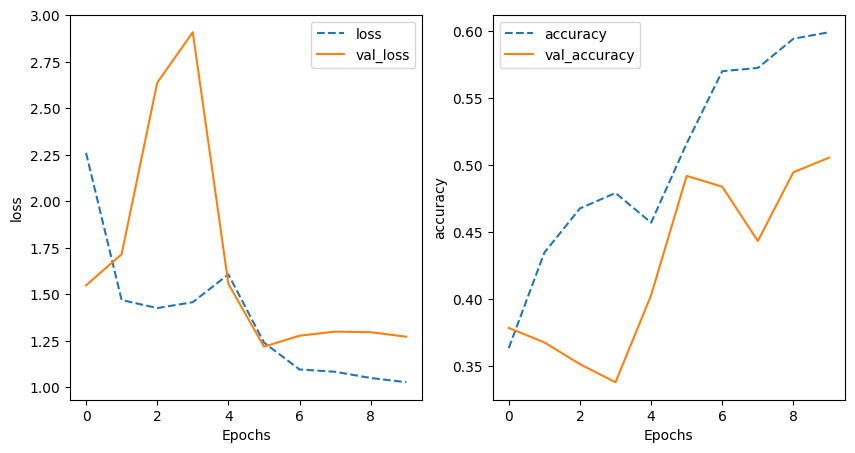

In [8]:
model = train_and_evaluate(batch_size=32, lrate=0.0001, l1=0, l2=0, num_hidden=128)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.3448 - loss: 2.6468 - val_accuracy: 0.4324 - val_loss: 1.3320
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.4330 - loss: 1.4178 - val_accuracy: 0.4270 - val_loss: 1.3282
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.4588 - loss: 1.3630 - val_accuracy: 0.4514 - val_loss: 1.2967
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.4948 - loss: 1.2638 - val_accuracy: 0.4730 - val_loss: 1.2920
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.5291 - loss: 1.1837 - val_accuracy: 0.4757 - val_loss: 1.2769
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.5521 - loss: 1.1314 - val_accuracy: 0.4703 - val_loss: 1.2760
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.5682 - loss: 1.0897 - val_accuracy: 0.4973 - val_loss: 1.3105
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.5958 - loss: 1.0497 - val_accu

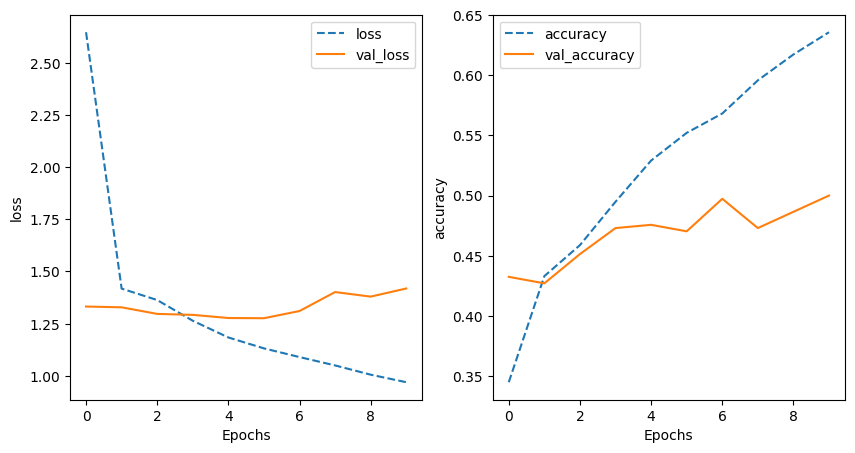

In [9]:
model = train_and_evaluate(batch_size=32, lrate=0.0001, l1=0, l2=0, num_hidden=256)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.3618 - loss: 2.2818 - val_accuracy: 0.3622 - val_loss: 2.2018
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.4391 - loss: 1.7754 - val_accuracy: 0.4270 - val_loss: 1.9401
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.4615 - loss: 1.7010 - val_accuracy: 0.3622 - val_loss: 2.1654
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.5012 - loss: 1.5303 - val_accuracy: 0.4216 - val_loss: 2.1011
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.5185 - loss: 1.4938 - val_accuracy: 0.4676 - val_loss: 1.9826
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.5318 - loss: 1.4102 - val_accuracy: 0.4730 - val_loss: 1.6544
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.5670 - loss: 1.3171 - val_accuracy: 0.4919 - val_loss: 1.6418
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.6109 - loss: 1.1820 - val_accu

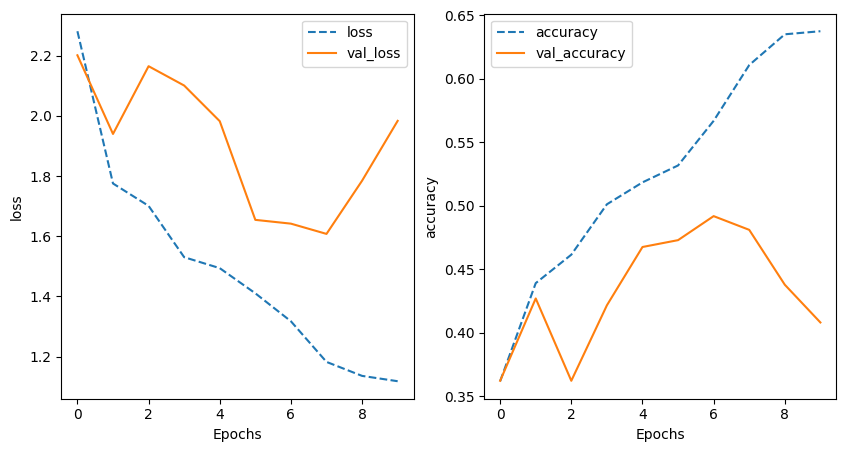

In [10]:
model = train_and_evaluate(batch_size=32, lrate=0.0001, l1=0, l2=0.001, num_hidden=128)

## Hyperparameter tuning

In [11]:
!pip install --quiet keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.4 MB/s eta 0:00:00


In [14]:
import kerastuner as kt

# parameterize to the values in the previous cell
def build_model(hp):
  lrate = hp.Float('lrate', 1e-5, 5e-4, sampling='log')
  l1 = 0
  l2 = hp.Choice('l2', values=[0.0, 1e-5, 1e-4, 1e-3])
  num_hidden = hp.Int('num_hidden', 32, 128, 32)

  regularizer = tf.keras.regularizers.l1_l2(l1, l2)

  # NN with one hidden layers
  model = tf.keras.Sequential([
              tf.keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
              tf.keras.layers.Dense(num_hidden,
                                    kernel_regularizer=regularizer,
                                    activation=tf.keras.activations.relu),
              tf.keras.layers.Dense(len(CLASS_NAMES),
                                    kernel_regularizer=regularizer,
                                    activation='softmax')
  ])
  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lrate),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                  metrics=['accuracy'])
  return model

batch_size = 32
train_dataset = (tf.data.TextLineDataset(
    "gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/train_set.csv").
    map(decode_csv)).batch(batch_size)

eval_dataset = (tf.data.TextLineDataset(
    "gs://practical-ml-vision-book-data/flowers_5_jpeg/flower_photos/eval_set.csv").
    map(decode_csv)).batch(32) # this doesn't matter

tuner = kt.BayesianOptimization(
    build_model,
    objective=kt.Objective('val_accuracy', 'max'),
    max_trials=10,
    num_initial_points=2,
    overwrite=False) # True to start afresh.

tuner.search(
    train_dataset, validation_data=eval_dataset,
    epochs=5,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3)]
)

topN = 1
for x in range(topN):
  print(tuner.get_best_hyperparameters(topN)[x].values)
  print(tuner.get_best_models(topN)[x].summary())

Trial 10 Complete [00h 10m 42s]
val_accuracy: 0.4648648500442505

Best val_accuracy So Far: 0.4648648500442505
Total elapsed time: 01h 47m 03s
{'lrate': 0.0001, 'l2': 0.0001, 'num_hidden': 256}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    38,535,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,536,709 (147.01 MB)

 Trainable params: 38,536,709 (147.01 MB)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best num_hidden:", best_hps.get("num_hidden"))
print("Best learning rate:", best_hps.get("lrate"))
print("Best l2:", best_hps.get("l2"))

Best num_hidden: 256
Best learning rate: 0.0001
Best l2: 0.0001


In [21]:
model = build_model(best_hps)
history = model.fit(
    train_dataset, validation_data = eval_dataset,
    epochs=10,
    batch_size=32
)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.3527 - loss: 2.8150 - val_accuracy: 0.4189 - val_loss: 2.2204
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.4297 - loss: 1.6577 - val_accuracy: 0.4243 - val_loss: 1.9437
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.4542 - loss: 1.5585 - val_accuracy: 0.4243 - val_loss: 1.9890
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.4927 - loss: 1.4348 - val_accuracy: 0.4297 - val_loss: 1.7508
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.5291 - loss: 1.3110 - val_accuracy: 0.4595 - val_loss: 1.5096
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.5627 - loss: 1.2403 - val_accuracy: 0.4514 - val_loss: 1.5294
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.5812 - loss: 1.2029 - val_accuracy: 0.4622 - val_loss: 1.4647
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.6148 - loss: 1.0967 - val_accu

# Explanation:
Even though the code is using the keras tuner it is using less epochs than the earlier model since there is a large search space so more epochs would take longer. In my solution I limit the hyperparameter ranges so we can increase epochs. However, after realizing how long this would take I keep my limited hyperparameter space as well as original epochs in the tuner, but retrain the model with more epochs using the best hyperparameters.


*   learning rate range of 1e-4 to 1e-1 updated to 1e-5 to 5e-4 (the best learning rate was .00017 and earlier models that performed better used .0001)
* limited l2 values (earlier models with l2 of 0.1 performed poorly)
* limited hidden units to 128 (once again earlier models did best with this)

If I was not limited in compute I would increase the epochs in the tuner from 5 to 15 (also increasing the early stopping patience to 3), as well as the max_trials to 15. However, this would take a very long time so instead I extracted the best hyperparameters, and retrained the model using 10 epochs. Considering validation accuracy was still increasing at 10 its possible it would continue to improve over more epochs.

*   Textbook validation accuracy: 0.4595
*   My validation accuracy before retraining: 0.4649
* My validation accuracy after retraining: 0.6573


To improve on this (especially given that this is a relatively small dataset), I would suggest implementing transfer learning.

